# Data Science Projects With Python

#### This is a study repository based on  the book __Data Science Projects With Python__.
#### we`ll explore the most important exercices and make reflections about the technical aspects of the lessons while we create new features and the systems that shows up during the process.
## Exercices 1 and 2 - inicial setup 

In [1]:
# import libraries

import pandas as pd

In [2]:
# Save URL
URL = "https://github.com/TrainingByPackt/Data-Science-Projects-with-Python/raw/refs/heads/master/Data/default_of_credit_card_clients__courseware_version_1_21_19.xls"

# load data
df = pd.read_excel(URL)


In [3]:
df.shape

(30000, 25)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30000 non-null  str   
 1   LIMIT_BAL                   30000 non-null  int64 
 2   SEX                         30000 non-null  int64 
 3   EDUCATION                   30000 non-null  int64 
 4   MARRIAGE                    30000 non-null  int64 
 5   AGE                         30000 non-null  int64 
 6   PAY_1                       30000 non-null  object
 7   PAY_2                       30000 non-null  int64 
 8   PAY_3                       30000 non-null  int64 
 9   PAY_4                       30000 non-null  int64 
 10  PAY_5                       30000 non-null  int64 
 11  PAY_6                       30000 non-null  int64 
 12  BILL_AMT1                   30000 non-null  int64 
 13  BILL_AMT2                   30000 non-null  int64 
 14  B

In [5]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# The problem:

Our client is a credit card company. They gave us a dataset that includes recent demographic and financial data (last 6 months) from a sample of 30.000 account holders. The data is at credit account level; in other words one row for each account. The rows are classified as
if the next month of the 6 months period the account holder was overdue, that is, did not pay the minimum amount.

### Our goal:
Our goal is to develop a model that forecasts if one account will be overdue for th next month according to the demographic data and history. Later in the book we'll discuss the practical application of the model. 


### Data Dictionary:

1. __ID__ : Customer identifier
2. __LIMIT_BAL__ : Total amount of the credit provided
3. __SEX__ : Gender - __It will not be used for analysis due to ethical issues.__
4. __EDUCATION__ : Highest level of curtomer's education 

     Value | Status |
    | :---: | :--- |
    | 1 | Postgraduate |
    | 2 | University/College |
    | 3 | Sencodary School  |
    | 4 | Other |
   
7. __MARIAGE__ :

    | Value | Status |
    | :---: | :--- |
    | 1 | Maried |
    | 2 | Single |
    | 3 | Other  |
   
8. __AGE__ : year of birth
9. __PAY_1–PAY_6__ : Previous monthly payments record. PAY_1 = Last payment, PAY_2 = Second Last payment and so on...
  
    | Value | Status |
    | :---: | :--- |
    | -2 | no balance to be paid |
    | 0 | partially paid|
    | -1 | paid |
    | 1 | 1 month late |
    | 2 | 2 months late |
    | 3 | 3 months late |
    | 4 | 4 months late |
    | 5 | 5 months late |

11. __BILL_AMT1–BILL_AMT6__ : Bill amount in TWD (New Taiwan dollar). BILL_AMT1 = September bill balance, BILL_AMT2 = August bill balance and so on...
12. __PAY_AMT1–PAY_AMT6__ : Payment amount in TWD (New Taiwan dollar). PAY_AMT1 = Septemper payment, PAY_AMT2 = August payment and so on...
   

## Exercice 3 - Checking basic data integrity

In [6]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

### EDA - Exploratory Data Analysis

Check for Primary Key repetitions

In [7]:
print(f"{'number of rows:':<30} {df.shape[0]}")
print(f"{'number od unique IDs:':<30} {df['ID'].nunique()}\n")

print(f"There are {df.shape[0] - df['ID'].nunique()} repeating data")

number of rows:                30000
number od unique IDs:          29687

There are 313 repeating data


In [8]:
id_count = df['ID'].value_counts()

In [9]:
id_count.value_counts()

count
1    29374
2      313
Name: count, dtype: int64

### Boolean mask

In [10]:
# import numpy to generate random integer array

import numpy as np

In [11]:
np.random.seed(seed=24)

In [12]:
random_integers = np.random.randint(low=1, high=5, size=100)

In [13]:
random_integers[:5]

array([3, 4, 1, 4, 2])

In [14]:
is_equal_to_3 = random_integers == 3

In [15]:
is_equal_to_3[0:5]

array([ True, False, False, False, False])

In [16]:
is_equal_to_3.sum()

np.int64(22)

## Exercice 4 - Continue data integrity analysis

### Apply boolean mask to df

In [17]:
dupe_mask = id_count == 2

In [18]:
dupe_ids = id_count.index[dupe_mask]

In [19]:
dupe_ids

Index(['26bde6da-f148', '42009c72-651f', '73ed1381-3a3f', '4f95b36b-ab10',
       '8d3a2576-a958', 'd5aeb496-64e5', 'ebda7f71-7024', '5b8dce34-2ded',
       '428b26a3-dca2', '94c4ece8-bba6',
       ...
       '8f9549b7-d5a4', '6d1fc219-67b0', '415c344e-309f', 'a9870d3e-b4d1',
       '9e6e766d-ba75', 'f12b9d9e-ada0', 'e7cd8c1a-88e9', '90330d02-82d9',
       'ad23fe5c-7b09', '97d1d2eb-c72f'],
      dtype='str', name='ID', length=313)

In [20]:
df.loc[df['ID'].isin(dupe_ids[:3]),:].head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
141,26bde6da-f148,180000,1,2,2,28,-1,-1,-1,-1,...,332,416,416,0,416,332,500,3500,832,0
196,42009c72-651f,150000,2,2,1,34,-2,-2,-2,-2,...,116,0,1500,0,0,116,0,1500,0,0
241,26bde6da-f148,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
296,42009c72-651f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
323,73ed1381-3a3f,230000,2,2,1,28,0,0,0,-2,...,2100,767,6173,1710,1100,1000,767,6173,1000,1
423,73ed1381-3a3f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
df_zero_mask = df == 0

In [22]:
df_zero_mask

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,True,True,True,True,False
1,False,False,False,False,False,False,False,False,True,True,...,False,False,False,True,False,False,False,True,False,False
2,False,False,False,False,False,False,True,True,True,True,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,True,True,True,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,False,False,False,False,False,False,True,True,True,True,...,False,False,False,False,False,False,False,False,False,True
29996,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
29997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
29998,False,False,False,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


In [23]:
feature_mask_zero = df_zero_mask.iloc[:,1:].all(axis=1)

In [24]:
feature_mask_zero

0        False
1        False
2        False
3        False
4        False
         ...  
29995    False
29996    False
29997    False
29998    False
29999    False
Length: 30000, dtype: bool

In [25]:
sum(feature_mask_zero)

315

In [26]:
df_clean_1 = df.loc[~feature_mask_zero,:].copy()

In [27]:
df_clean_1.shape

(29685, 25)

In [28]:
df_clean_1['ID'].nunique()

29685

## Exercice 5 - Exploring and Cleaning the data

In [29]:
df_clean_1.info()

<class 'pandas.DataFrame'>
Index: 29685 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          29685 non-null  str   
 1   LIMIT_BAL                   29685 non-null  int64 
 2   SEX                         29685 non-null  int64 
 3   EDUCATION                   29685 non-null  int64 
 4   MARRIAGE                    29685 non-null  int64 
 5   AGE                         29685 non-null  int64 
 6   PAY_1                       29685 non-null  object
 7   PAY_2                       29685 non-null  int64 
 8   PAY_3                       29685 non-null  int64 
 9   PAY_4                       29685 non-null  int64 
 10  PAY_5                       29685 non-null  int64 
 11  PAY_6                       29685 non-null  int64 
 12  BILL_AMT1                   29685 non-null  int64 
 13  BILL_AMT2                   29685 non-null  int64 
 14  BILL_A

In [30]:
df_clean_1['PAY_1'].head()

0     2
1    -1
2     0
3     0
4    -1
Name: PAY_1, dtype: object

In [31]:
df_clean_1['PAY_1'].value_counts()

PAY_1
0                13087
-1                5047
1                 3261
Not available     3021
-2                2476
2                 2378
3                  292
4                   63
5                   23
8                   17
6                   11
7                    9
Name: count, dtype: int64

In [32]:
valid_pay_mask = df_clean_1['PAY_1'] != 'Not available'

In [33]:
valid_pay_mask.head()

0    True
1    True
2    True
3    True
4    True
Name: PAY_1, dtype: bool

In [34]:
sum(valid_pay_mask)

26664

In [35]:
df_clean_2 = df_clean_1.loc[valid_pay_mask,:].copy()

In [36]:
df_clean_2.shape

(26664, 25)

In [37]:
df_clean_2['PAY_1'].value_counts()

PAY_1
0     13087
-1     5047
1      3261
-2     2476
2      2378
3       292
4        63
5        23
8        17
6        11
7         9
Name: count, dtype: int64

In [38]:
df_clean_2['PAY_1'] = df_clean_2['PAY_1'].astype(int)

In [39]:
df_clean_2.info()

<class 'pandas.DataFrame'>
Index: 26664 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          26664 non-null  str  
 1   LIMIT_BAL                   26664 non-null  int64
 2   SEX                         26664 non-null  int64
 3   EDUCATION                   26664 non-null  int64
 4   MARRIAGE                    26664 non-null  int64
 5   AGE                         26664 non-null  int64
 6   PAY_1                       26664 non-null  int64
 7   PAY_2                       26664 non-null  int64
 8   PAY_3                       26664 non-null  int64
 9   PAY_4                       26664 non-null  int64
 10  PAY_5                       26664 non-null  int64
 11  PAY_6                       26664 non-null  int64
 12  BILL_AMT1                   26664 non-null  int64
 13  BILL_AMT2                   26664 non-null  int64
 14  BILL_AMT3             

In [40]:
df_clean_2[['PAY_1', 'PAY_2']].info()

<class 'pandas.DataFrame'>
Index: 26664 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   PAY_1   26664 non-null  int64
 1   PAY_2   26664 non-null  int64
dtypes: int64(2)
memory usage: 624.9 KB


## Exercice 6 - Exploring credit limit and demographic features

In [41]:
import matplotlib.pyplot as plt #import plotting package
%matplotlib inline

In [42]:
import matplotlib as mpl #additional plotting resources

In [43]:
mpl.rcParams['figure.dpi'] = 400 #high definition figures

### Plotting the histograms

array([[<Axes: title={'center': 'LIMIT_BAL'}>,
        <Axes: title={'center': 'AGE'}>]], dtype=object)

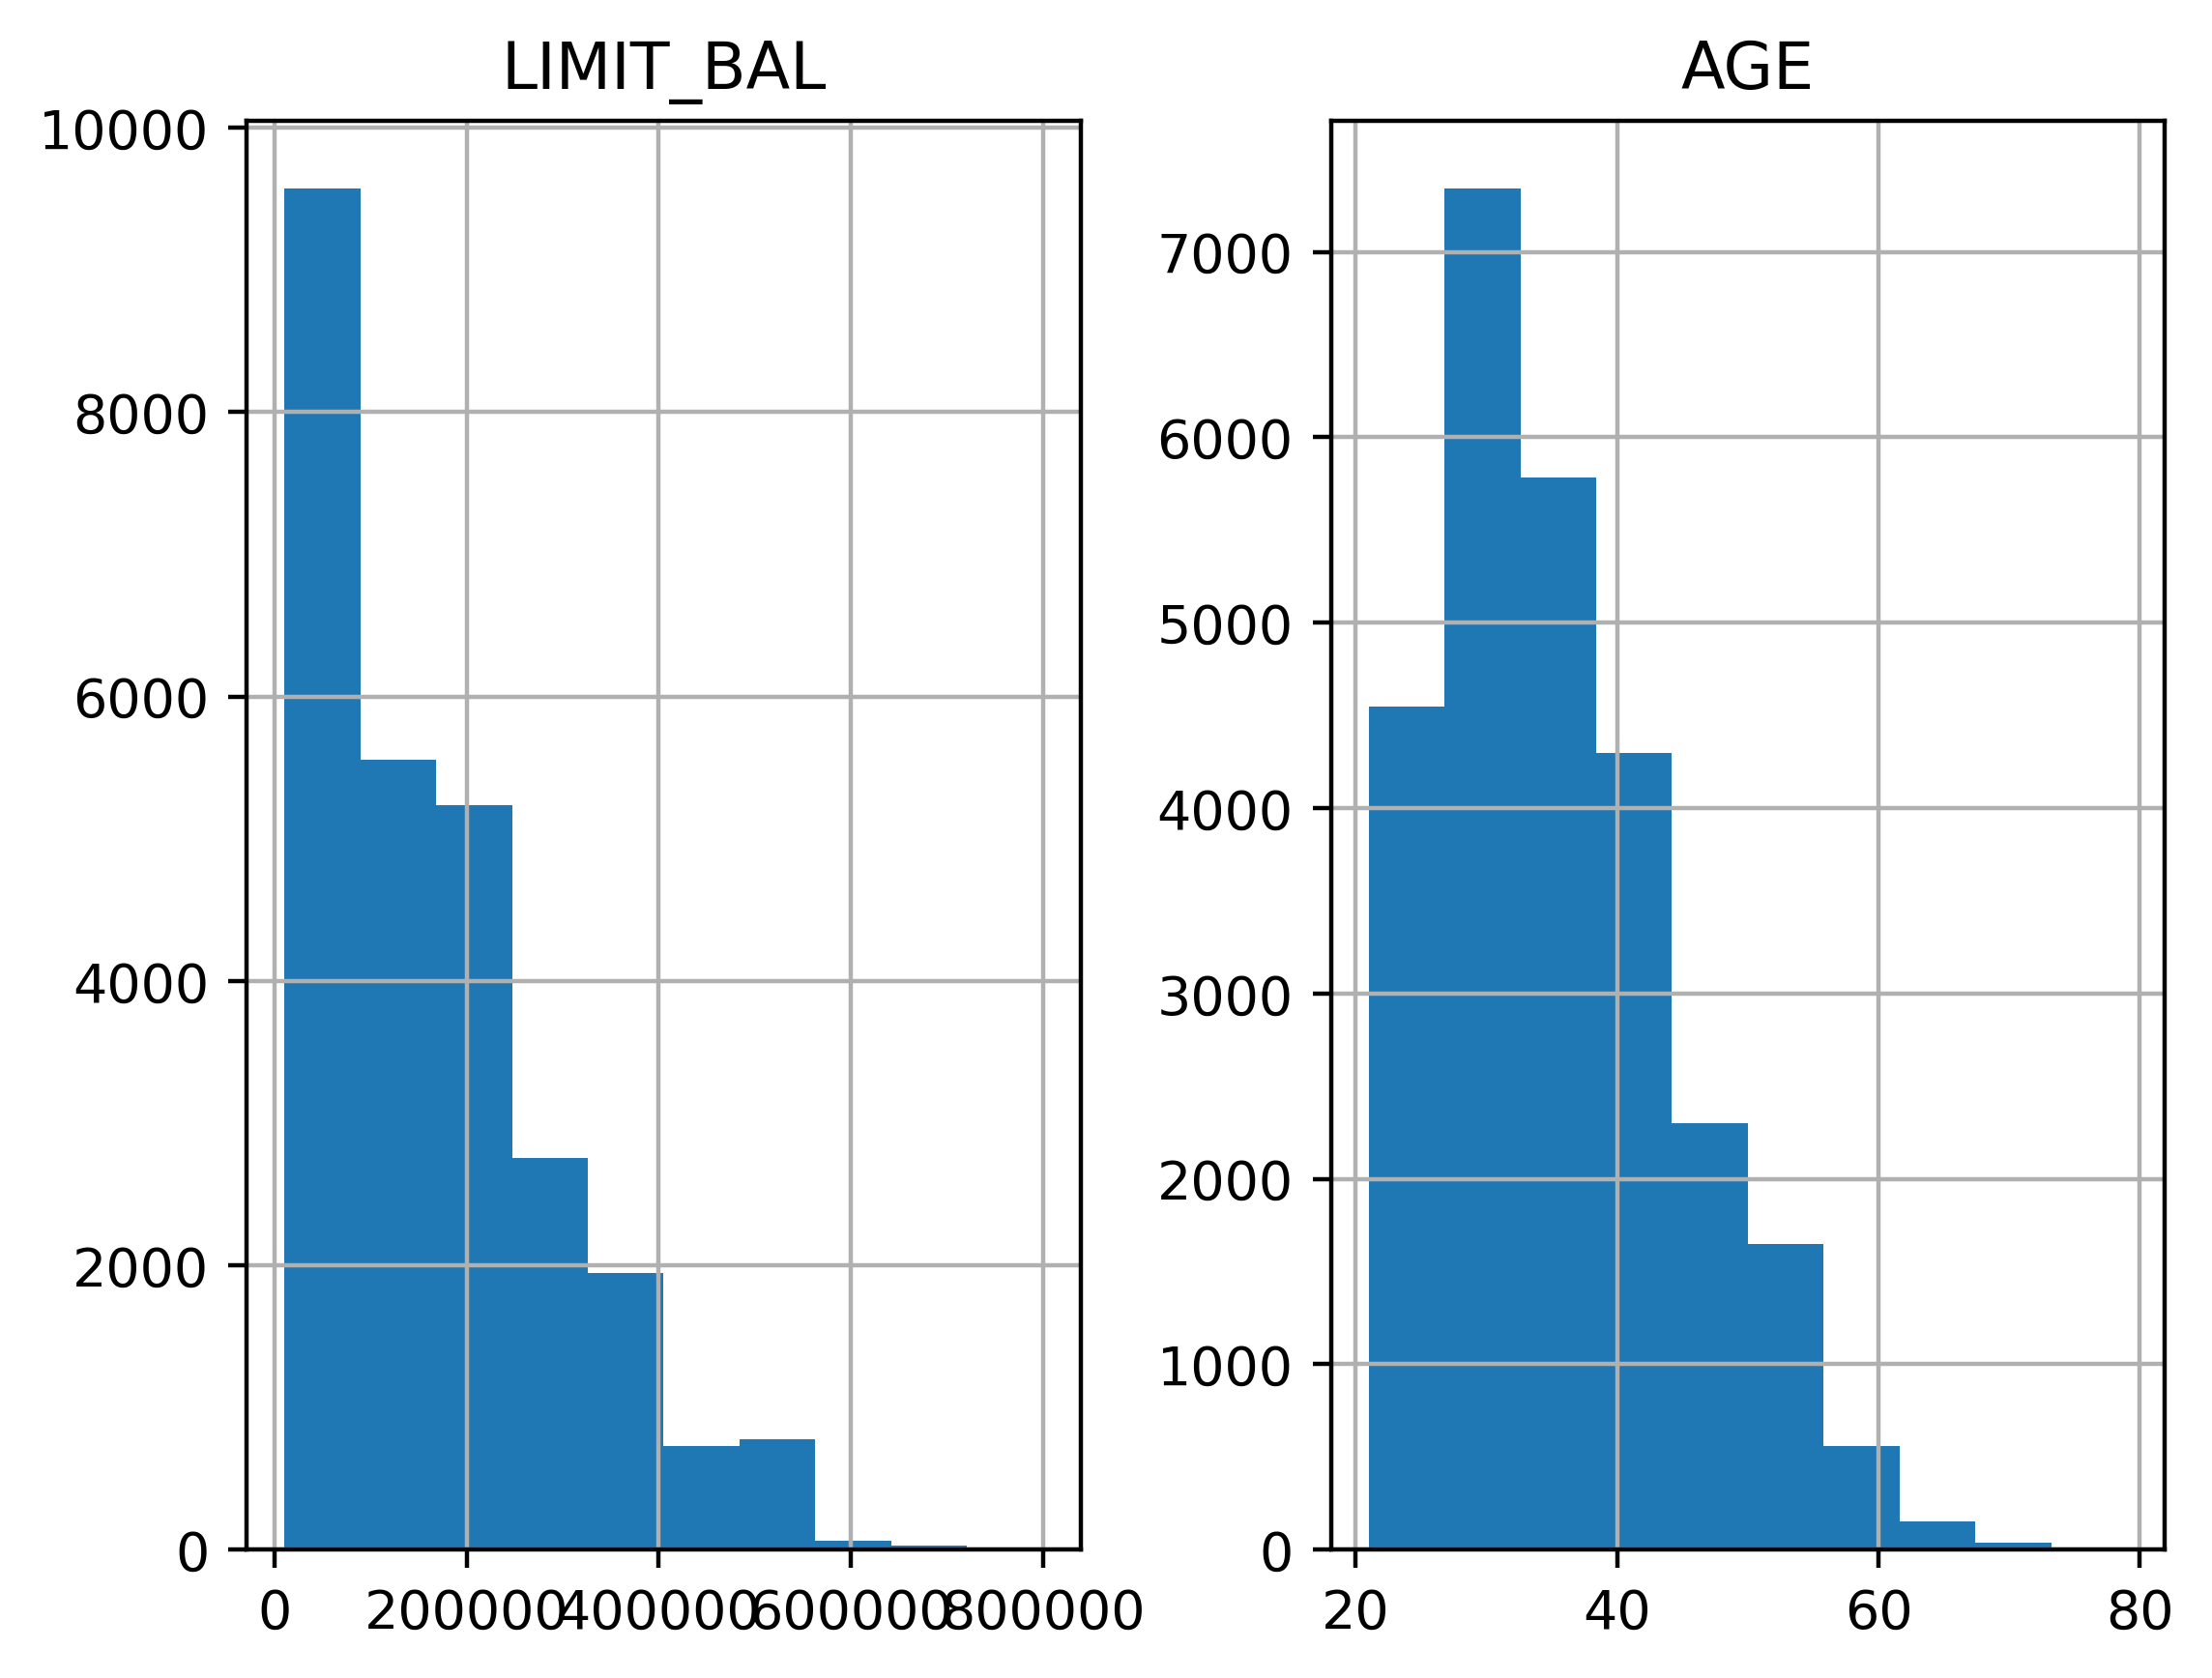

In [44]:
df_clean_2[['LIMIT_BAL', 'AGE']].hist()

In [45]:
df_clean_2[['LIMIT_BAL', 'AGE']].describe()

,LIMIT_BAL,AGE
count,26664.000000,26664.000000
mean,167919.054905,35.505213
std,129839.453081,9.227442
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,800000.000000,79.000000


### Converting currency from TWD to CAD

In [46]:
df_clean_2.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [47]:
monetary_cols = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [48]:
# convertion_rate = 0.044
# df_clean_2[monetary_cols] = df_clean_2[monetary_cols] * convertion_rate
# df_clean_2[monetary_cols] = df_clean_2[monetary_cols].astype(int)

In [49]:
df_clean_2.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [50]:
map_cols = {col: f"{col}_CAD" for col in monetary_cols}

In [56]:
df_clean_2.rename(columns=map_cols, inplace=True)

In [57]:
df_clean_2.head()

,ID,LIMIT_BAL_CAD,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4_CAD,BILL_AMT5_CAD,BILL_AMT6_CAD,PAY_AMT1_CAD,PAY_AMT2_CAD,PAY_AMT3_CAD,PAY_AMT4_CAD,PAY_AMT5_CAD,PAY_AMT6_CAD,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Getting Education unique values

In [60]:
df_clean_2['EDUCATION'].value_counts()

EDUCATION
2    12458
1     9412
3     4380
5      245
4      115
6       43
0       11
Name: count, dtype: int64

In [64]:
df_clean_2['EDUCATION'] = df_clean_2['EDUCATION'].replace(to_replace=[0,5,6], value=4)

In [67]:
df_clean_2['EDUCATION'].value_counts()

EDUCATION
2    12458
1     9412
3     4380
4      414
Name: count, dtype: int64